### Data Loading

In [ ]:
import pandas as pd

load_df = pd.read_csv("data/force/f_train.csv")
drop_columns = ['RSHA', 'RMED', 'GR', 'PEF', 'SP', 'ROP', 'DRHO', 'RDEP', 'WELL']
load_df = load_df.drop(drop_columns, axis=1)
load_df = load_df.dropna()
df = load_df.copy()

# Categorize Lithology
litho_code = {30000: "Sandstone", 65030: "SandstoneShale", 65000: "Shale", 80000: "Marl", 
            74000: "Dolomite", 70000: "Limestone", 70032: "Chalk", 88000: "Halite", 
            86000: "Anhydrite", 99000: "Tuff", 90000: "Coal", 93000: "Basement"}
df["LITHOLOGY"] = df["LITHOLOGY"].map(litho_code)

df = df[df.LITHOLOGY != "Shale"]
df = df.reset_index(drop=True)
# Label encoder for 'GROUP', 'FORMATION', 'BS'
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['GROUP'] = le.fit_transform(df['GROUP'])
df['FORMATION'] = le.fit_transform(df['FORMATION'])
df['BS'] = le.fit_transform(df['BS'])

# drop = ['DEPTH_MD','CALI', 'RHOB', 'NPHI', 'DTC']
# dt_df = df.drop(drop, axis=1)
load_df[:500].to_csv("data/dt/dt_before.csv", index=False)
load_df.head()

,DEPTH_MD,GROUP,FORMATION,CALI,RHOB,NPHI,DTC,BS,LITHOLOGY
0,1149.648,HORDALAND GP.,Utsira Fm.,17.482092,2.063168,0.541850,134.226379,17.5,65000
1,1149.800,HORDALAND GP.,Utsira Fm.,17.395611,2.051136,0.545401,134.824799,17.5,65000
2,1149.952,HORDALAND GP.,Utsira Fm.,17.364607,2.041540,0.548953,135.037079,17.5,65000
3,1150.104,HORDALAND GP.,Utsira Fm.,17.371887,2.035698,0.549356,134.500336,17.5,65000
4,1150.256,HORDALAND GP.,Utsira Fm.,17.370705,2.029099,0.543351,132.162399,17.5,65000


In [173]:
dt_df = df.copy()
dt_df[:500].to_csv("data/dt/dt_after.csv", index=False)
dt_df.head(20)

,DEPTH_MD,GROUP,FORMATION,CALI,RHOB,NPHI,DTC,BS,LITHOLOGY
0,1151.928,3,25,17.363323,2.000440,0.589035,133.393707,4,SandstoneShale
1,1152.080,3,25,17.306395,2.007255,0.595443,135.019684,4,SandstoneShale
2,1152.232,3,25,17.303955,2.017085,0.610448,136.660767,4,SandstoneShale
3,1152.384,3,25,17.368221,2.027622,0.614587,136.615814,4,SandstoneShale
4,1152.536,3,25,17.433296,2.033576,0.600994,134.936020,4,SandstoneShale
5,1159.376,3,25,17.332830,1.993782,0.633213,141.699799,4,SandstoneShale
6,1159.528,3,25,17.305010,1.981597,0.596889,141.424210,4,SandstoneShale
7,1160.440,3,25,17.648685,1.926005,0.550250,140.952103,4,SandstoneShale
8,1160.592,3,25,17.555012,1.899559,0.561272,142.641083,4,SandstoneShale
9,1168.344,3,25,17.534988,2.004711,0.587427,138.450134,4,SandstoneShale


### Train-Test Splitting

In [89]:
from sklearn.model_selection import train_test_split
# Split the dataset into training and testing sets
X = dt_df.drop("LITHOLOGY", axis=1)
y = dt_df["LITHOLOGY"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Decision Tree Model

In [90]:
from sklearn.tree import DecisionTreeClassifier

DT = DecisionTreeClassifier(max_depth=3)
DTModel = DT.fit(X_train, y_train)

feature_names = X_train.columns.values
class_names = DTModel.classes_
print("Feature name:", feature_names, "\nClasses:", class_names)

Feature name: ['DEPTH_MD' 'GROUP' 'FORMATION' 'CALI' 'RHOB' 'NPHI' 'DTC' 'BS'] 
Classes: ['Chalk' 'Coal' 'Dolomite' 'Limestone' 'Marl' 'Sandstone' 'SandstoneShale'
 'Tuff']


### Plotting

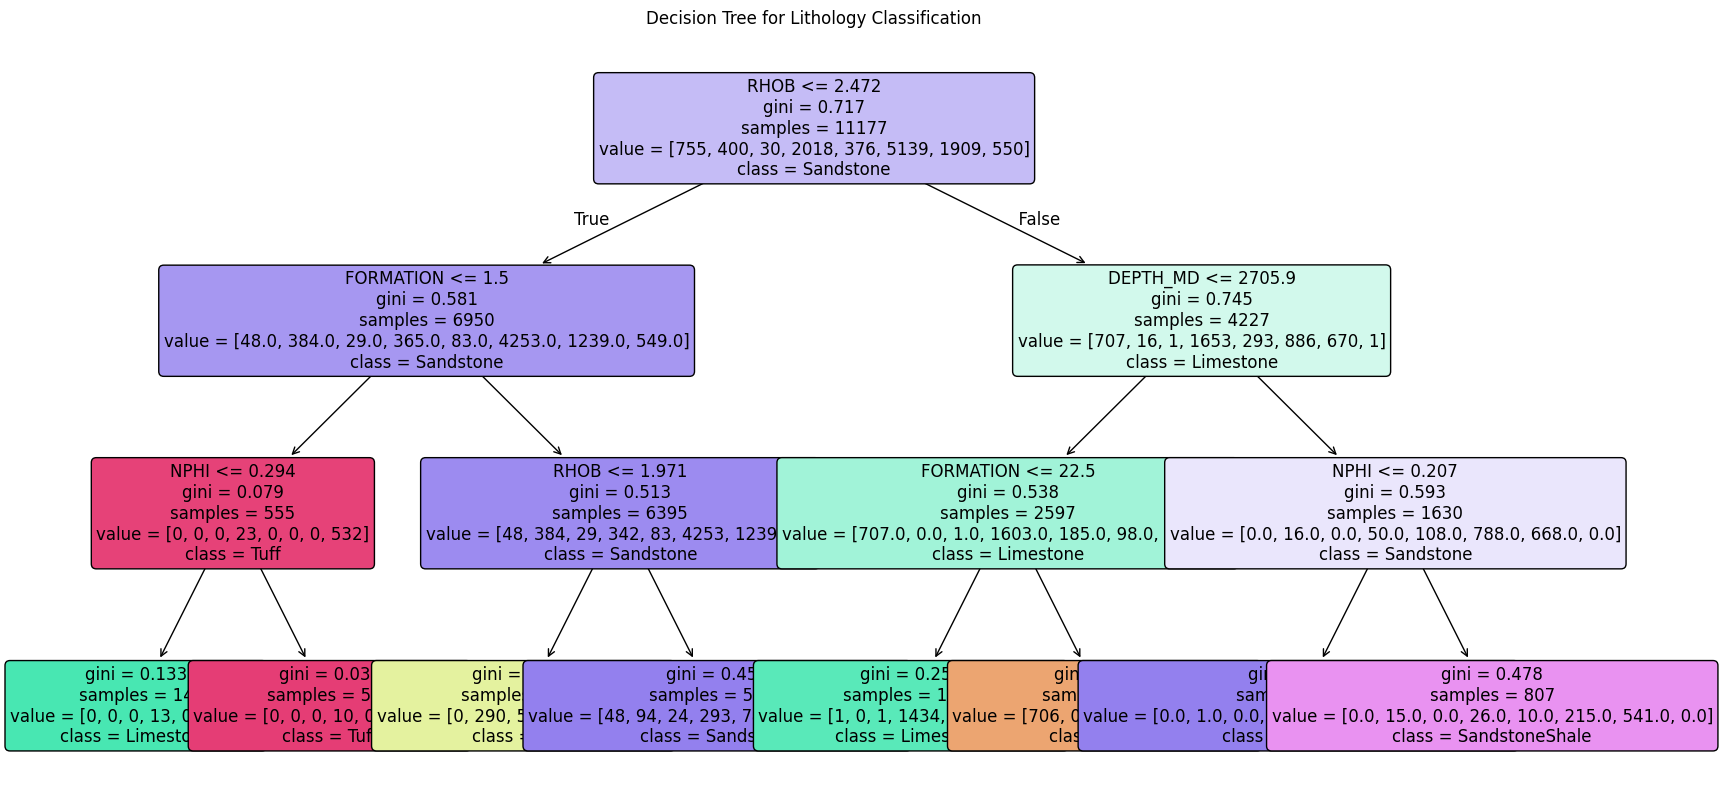

In [91]:
# Tree plot
from sklearn import tree
import matplotlib.pyplot as plt
plt.figure(figsize=(20, 10))
tree.plot_tree(DTModel, feature_names=feature_names, class_names=class_names, 
               filled=True, rounded=True, fontsize=12)
plt.title("Decision Tree for Lithology Classification")
plt.show()

### Inference

In [92]:
prediction = DTModel.predict(X_test)
print(prediction)

['Sandstone' 'Coal' 'Sandstone' ... 'Sandstone' 'Sandstone' 'Limestone']


In [93]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, prediction)
print(f"Accuracy of the model on test data: {accuracy:.2f}")

Accuracy of the model on test data: 0.74


In [94]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

Actual_Labels = y_test
Predicted_Labels = prediction
##Create the Basic Confusion Matrix
My_Conf_Mat = confusion_matrix(Actual_Labels, Predicted_Labels)
print(My_Conf_Mat)

[[ 175    0    0    0    0   14    0    0]
 [   0   77    0    0    0   21    2    0]
 [   0    2    0    0    0    5    0    0]
 [  53   12    0  348    0   86    4    2]
 [   5    5    0   34    0   44    6    0]
 [   1   14    0   18    0 1203   49    0]
 [   0   20    0    0    0  318  139    0]
 [   0    0    0    1    0    5    0  132]]


#### Confusion Matrix

Text(50.72222222222221, 0.5, 'Predicted')

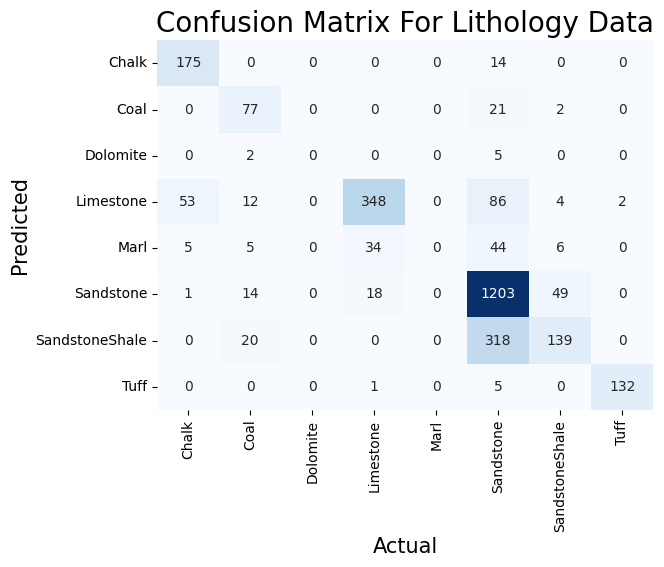

In [95]:
import seaborn as sns

##Create the fancy CM using Seaborn
sns.heatmap(My_Conf_Mat, annot=True, fmt='g', cmap='Blues', xticklabels=class_names, 
            yticklabels=class_names, cbar=False)

plt.title("Confusion Matrix For Lithology Data",fontsize=20)
plt.xlabel("Actual", fontsize=15)
plt.ylabel("Predicted", fontsize=15)

# plt.savefig("seaborn_plot.jpg")
# plt.close()

### Max Depth Hypertuning

In [163]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns

# Function to plot confusion matrix
def plot_confusion_matrix(cm, model_num):
    plt.figure(figsize=(12,10))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix - Decision Tree (Max Depth = {model_num})')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

Accuracy of Decision Tree 1: 0.7420


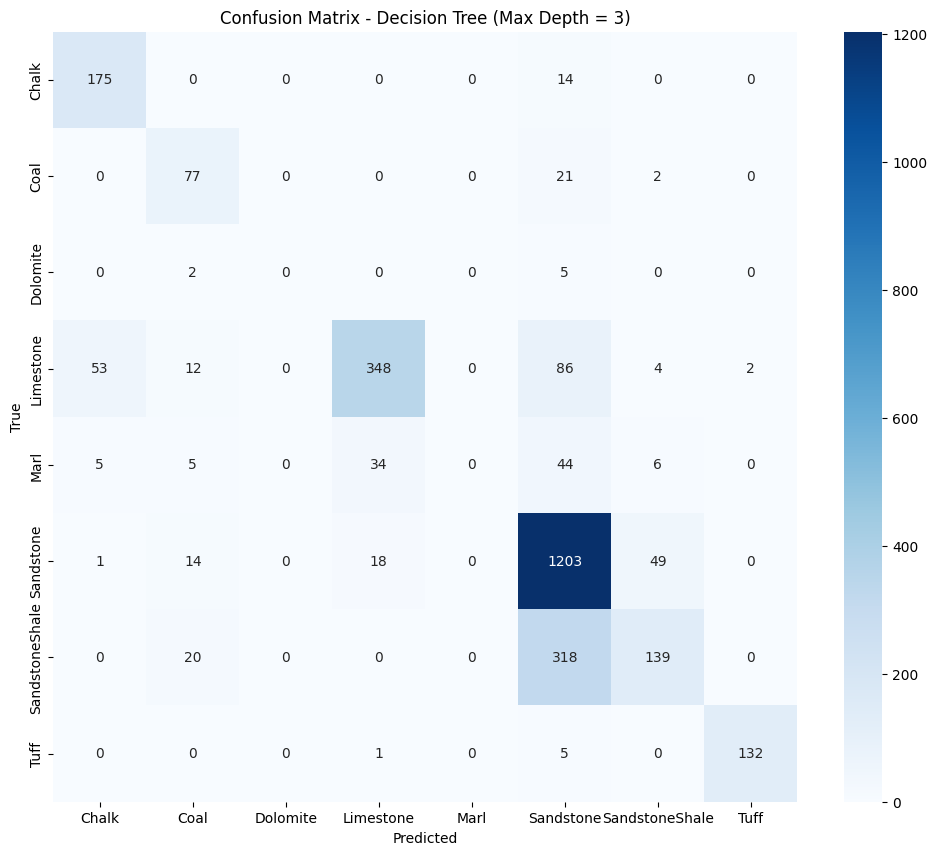

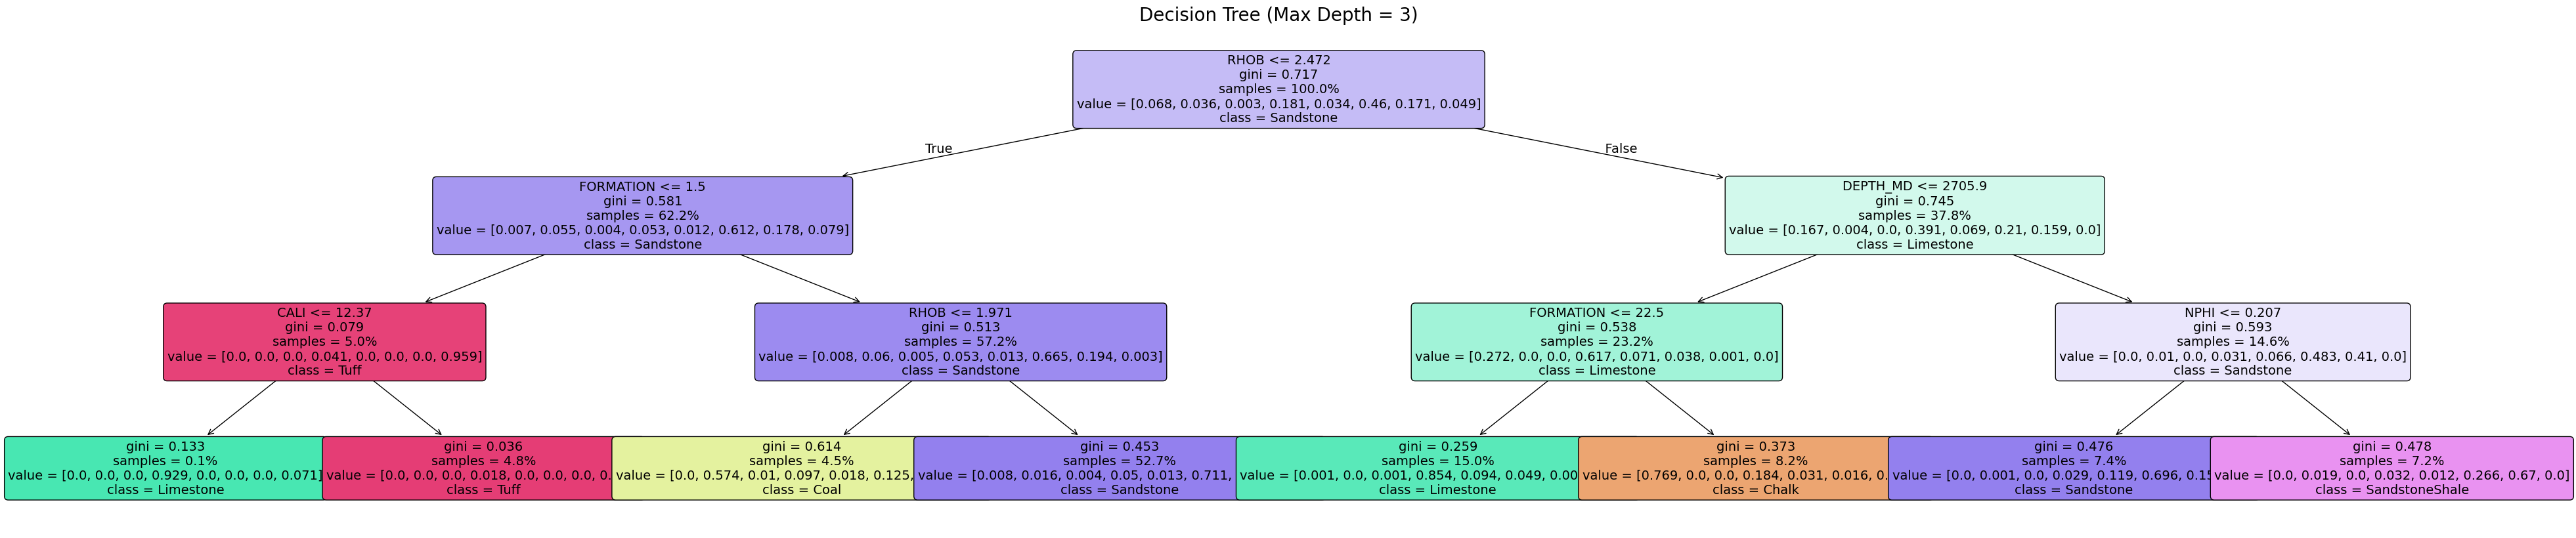

In [164]:
# Train three different models with different hyperparameters
DT1 = DecisionTreeClassifier(max_depth=3, random_state=42)
DTModel1 = DT1.fit(X_train, y_train)
y_pred1 = DTModel1.predict(X_test)
acc1 = accuracy_score(y_test, y_pred1)
print(f"Accuracy of Decision Tree 1: {acc1:.4f}")
cm1 = confusion_matrix(y_test, y_pred1)
plot_confusion_matrix(cm1, 3)

# Visualize Decision Trees with larger nodes
plt.figure(figsize=(50, 10)) 
plot_tree(DTModel1, feature_names=feature_names, class_names=class_names, filled=True, rounded=True, fontsize=14, impurity=True, proportion=True)
plt.title("Decision Tree (Max Depth = 3)", fontsize=20)
plt.show()


Accuracy of Decision Tree 2: 0.7828


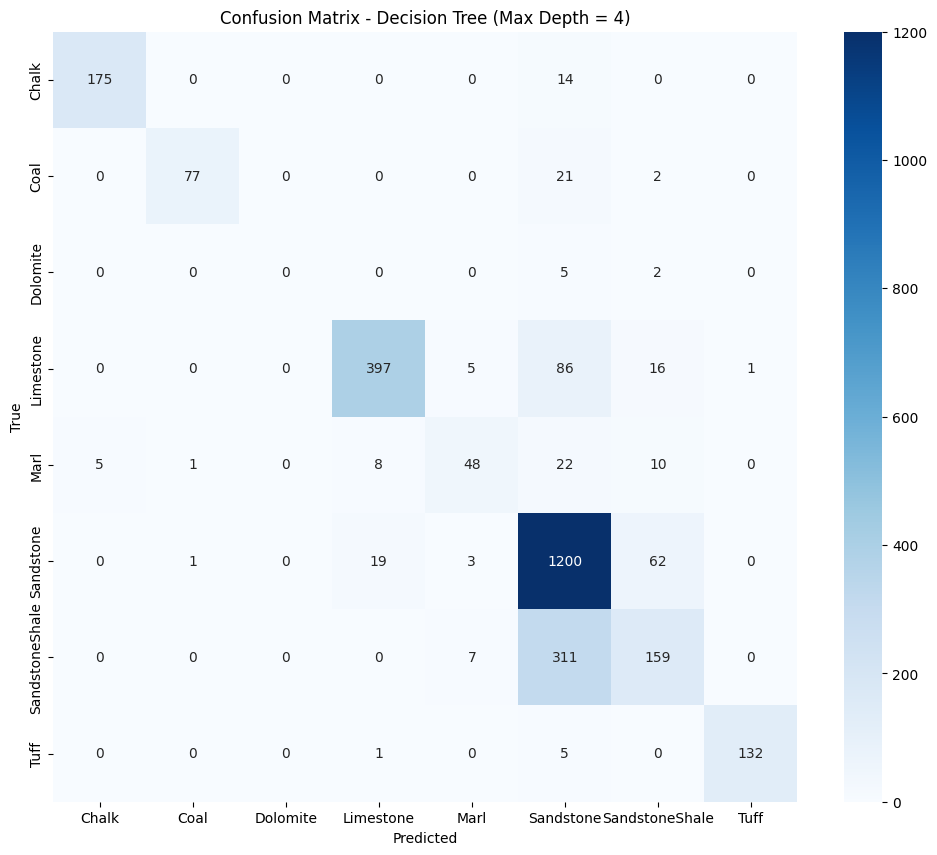

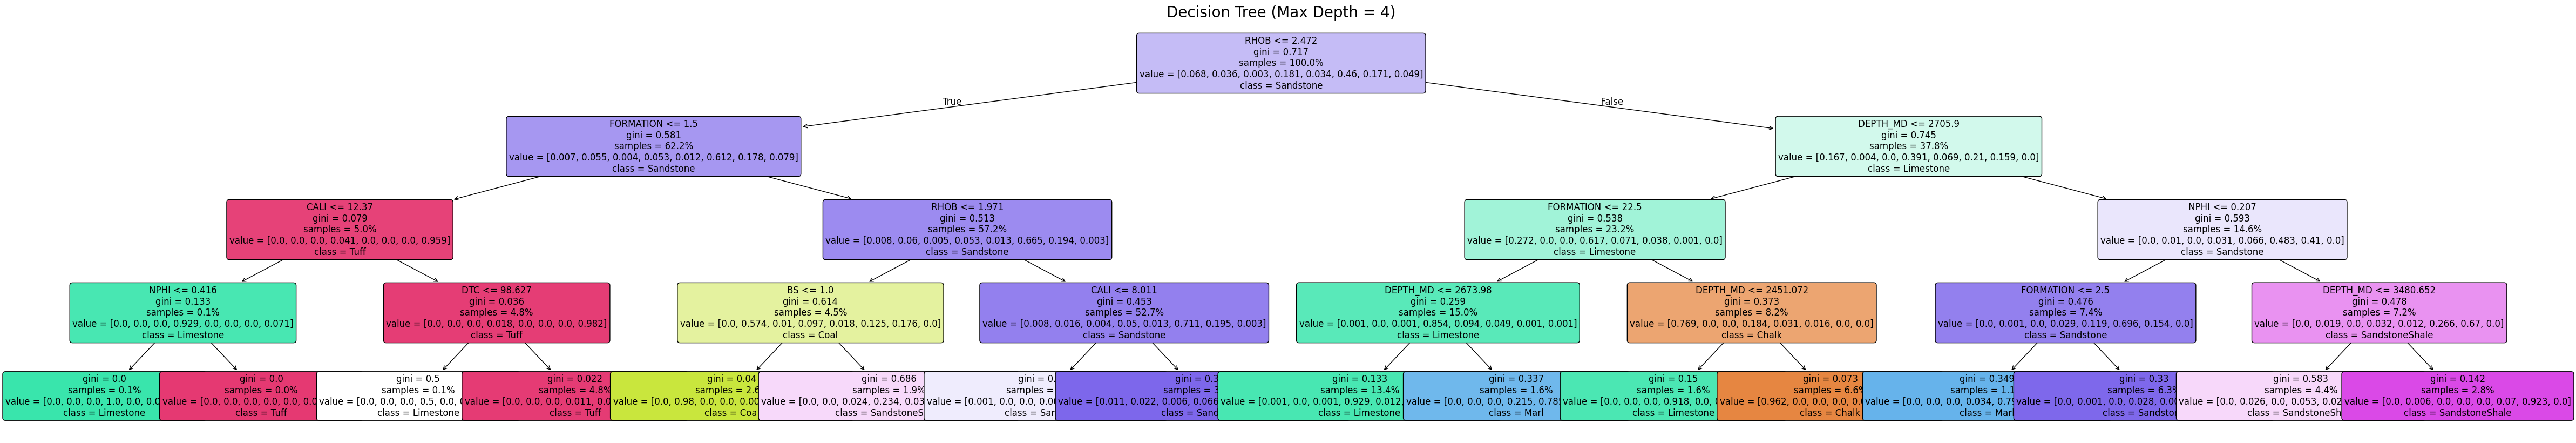

In [167]:
DT2 = DecisionTreeClassifier(max_depth=4, min_samples_split=2, random_state=42)
# Fit model
DTModel2 = DT2.fit(X_train, y_train)
# Predictions for evaluation
y_pred3 = DTModel2.predict(X_test)
# Accuracy calculation
acc3 = accuracy_score(y_test, y_pred3)
# Print accuracy
print(f"Accuracy of Decision Tree 2: {acc3:.4f}")
# Confusion matrix for each model
cm3 = confusion_matrix(y_test, y_pred3)
# Plot confusion matrices
plot_confusion_matrix(cm3, 4)
# Plot decision tree
plt.figure(figsize=(60, 10)) 
plot_tree(DTModel2, feature_names=feature_names, class_names=class_names, filled=True, rounded=True, fontsize=12, impurity=True, proportion=True)
plt.title("Decision Tree (Max Depth = 4)", fontsize=20)
plt.show()

Accuracy of Decision Tree 3: 0.8136


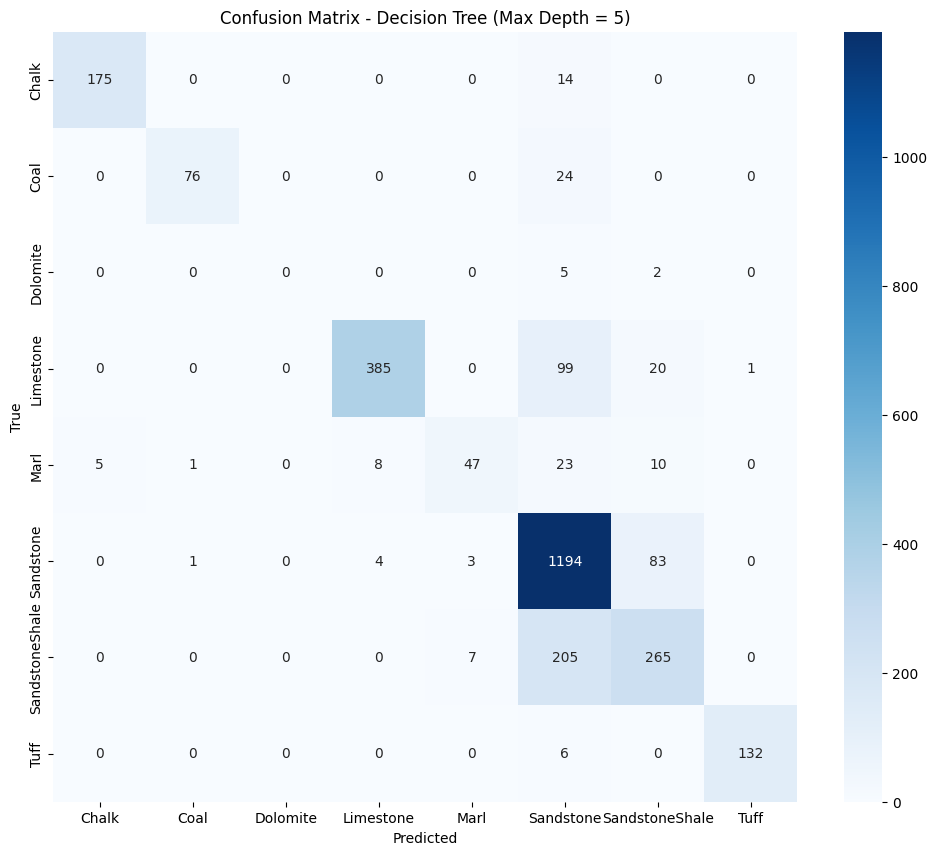

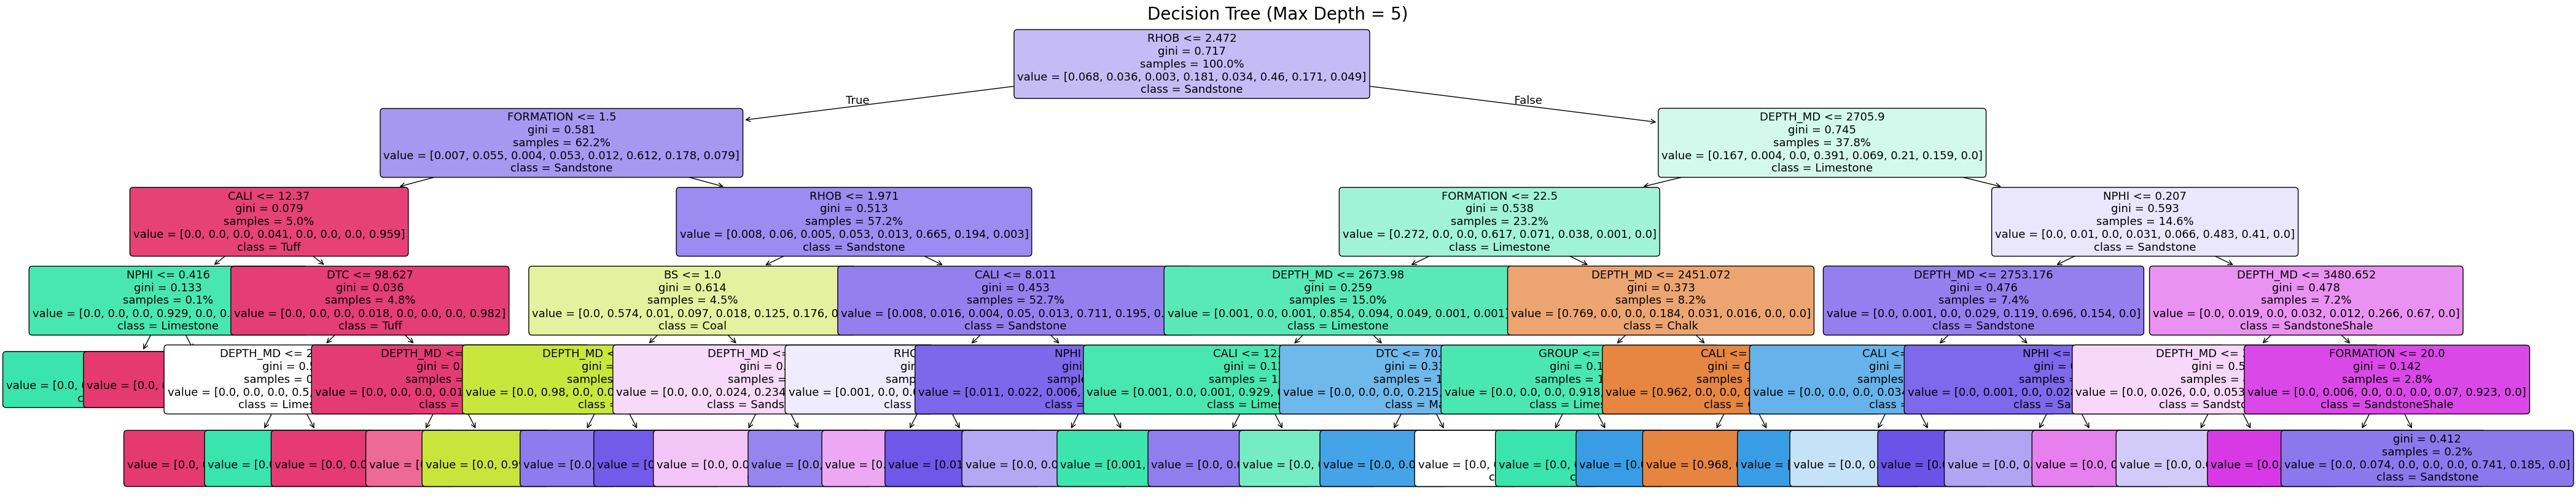

In [169]:
DT3 = DecisionTreeClassifier(max_depth=5, min_samples_split=4, random_state=42)
# Fit model
DTModel3 = DT3.fit(X_train, y_train)
# Predictions for evaluation
y_pred2 = DTModel3.predict(X_test)
# Accuracy calculation
acc2 = accuracy_score(y_test, y_pred2)
# Print accuracy
print(f"Accuracy of Decision Tree 3: {acc2:.4f}")
# Confusion matrix for each model
cm2 = confusion_matrix(y_test, y_pred2)
# Plot confusion matrices
plot_confusion_matrix(cm2, 5)
# Plot decision tree
plt.figure(figsize=(50, 10)) 
plot_tree(DTModel3, feature_names=feature_names, class_names=class_names, filled=True, rounded=True, fontsize=13, impurity=True, proportion=True)
plt.title("Decision Tree (Max Depth = 5)", fontsize=20)
plt.show()

Accuracy of Decision Tree 3: 0.9009


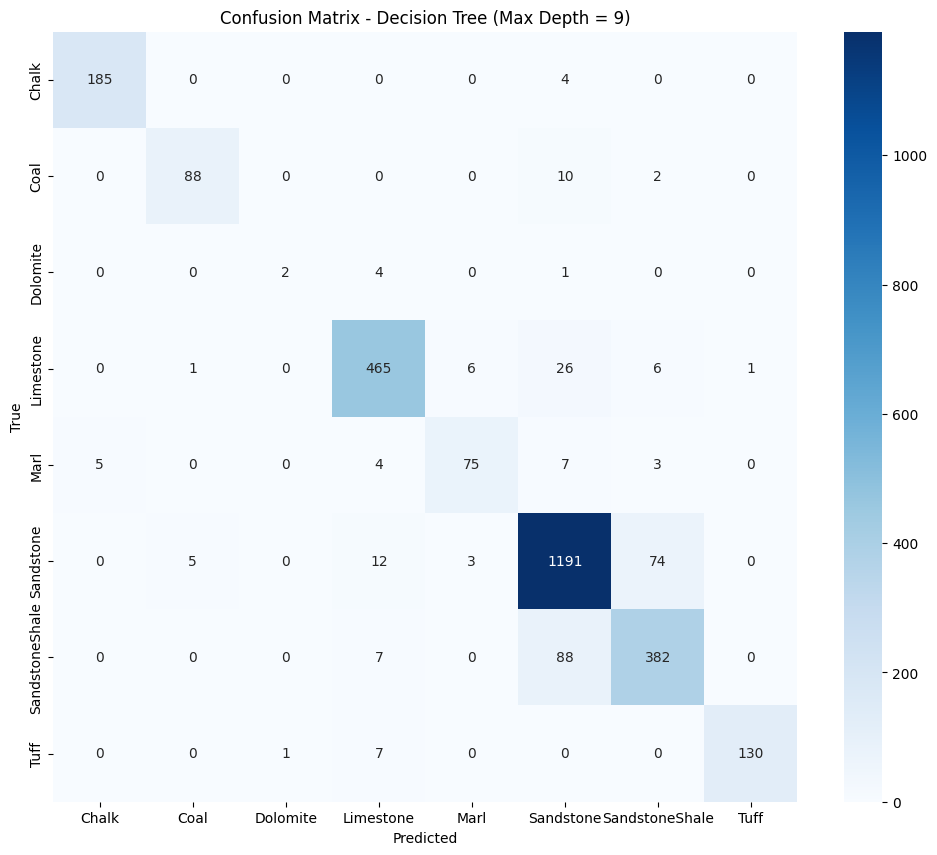

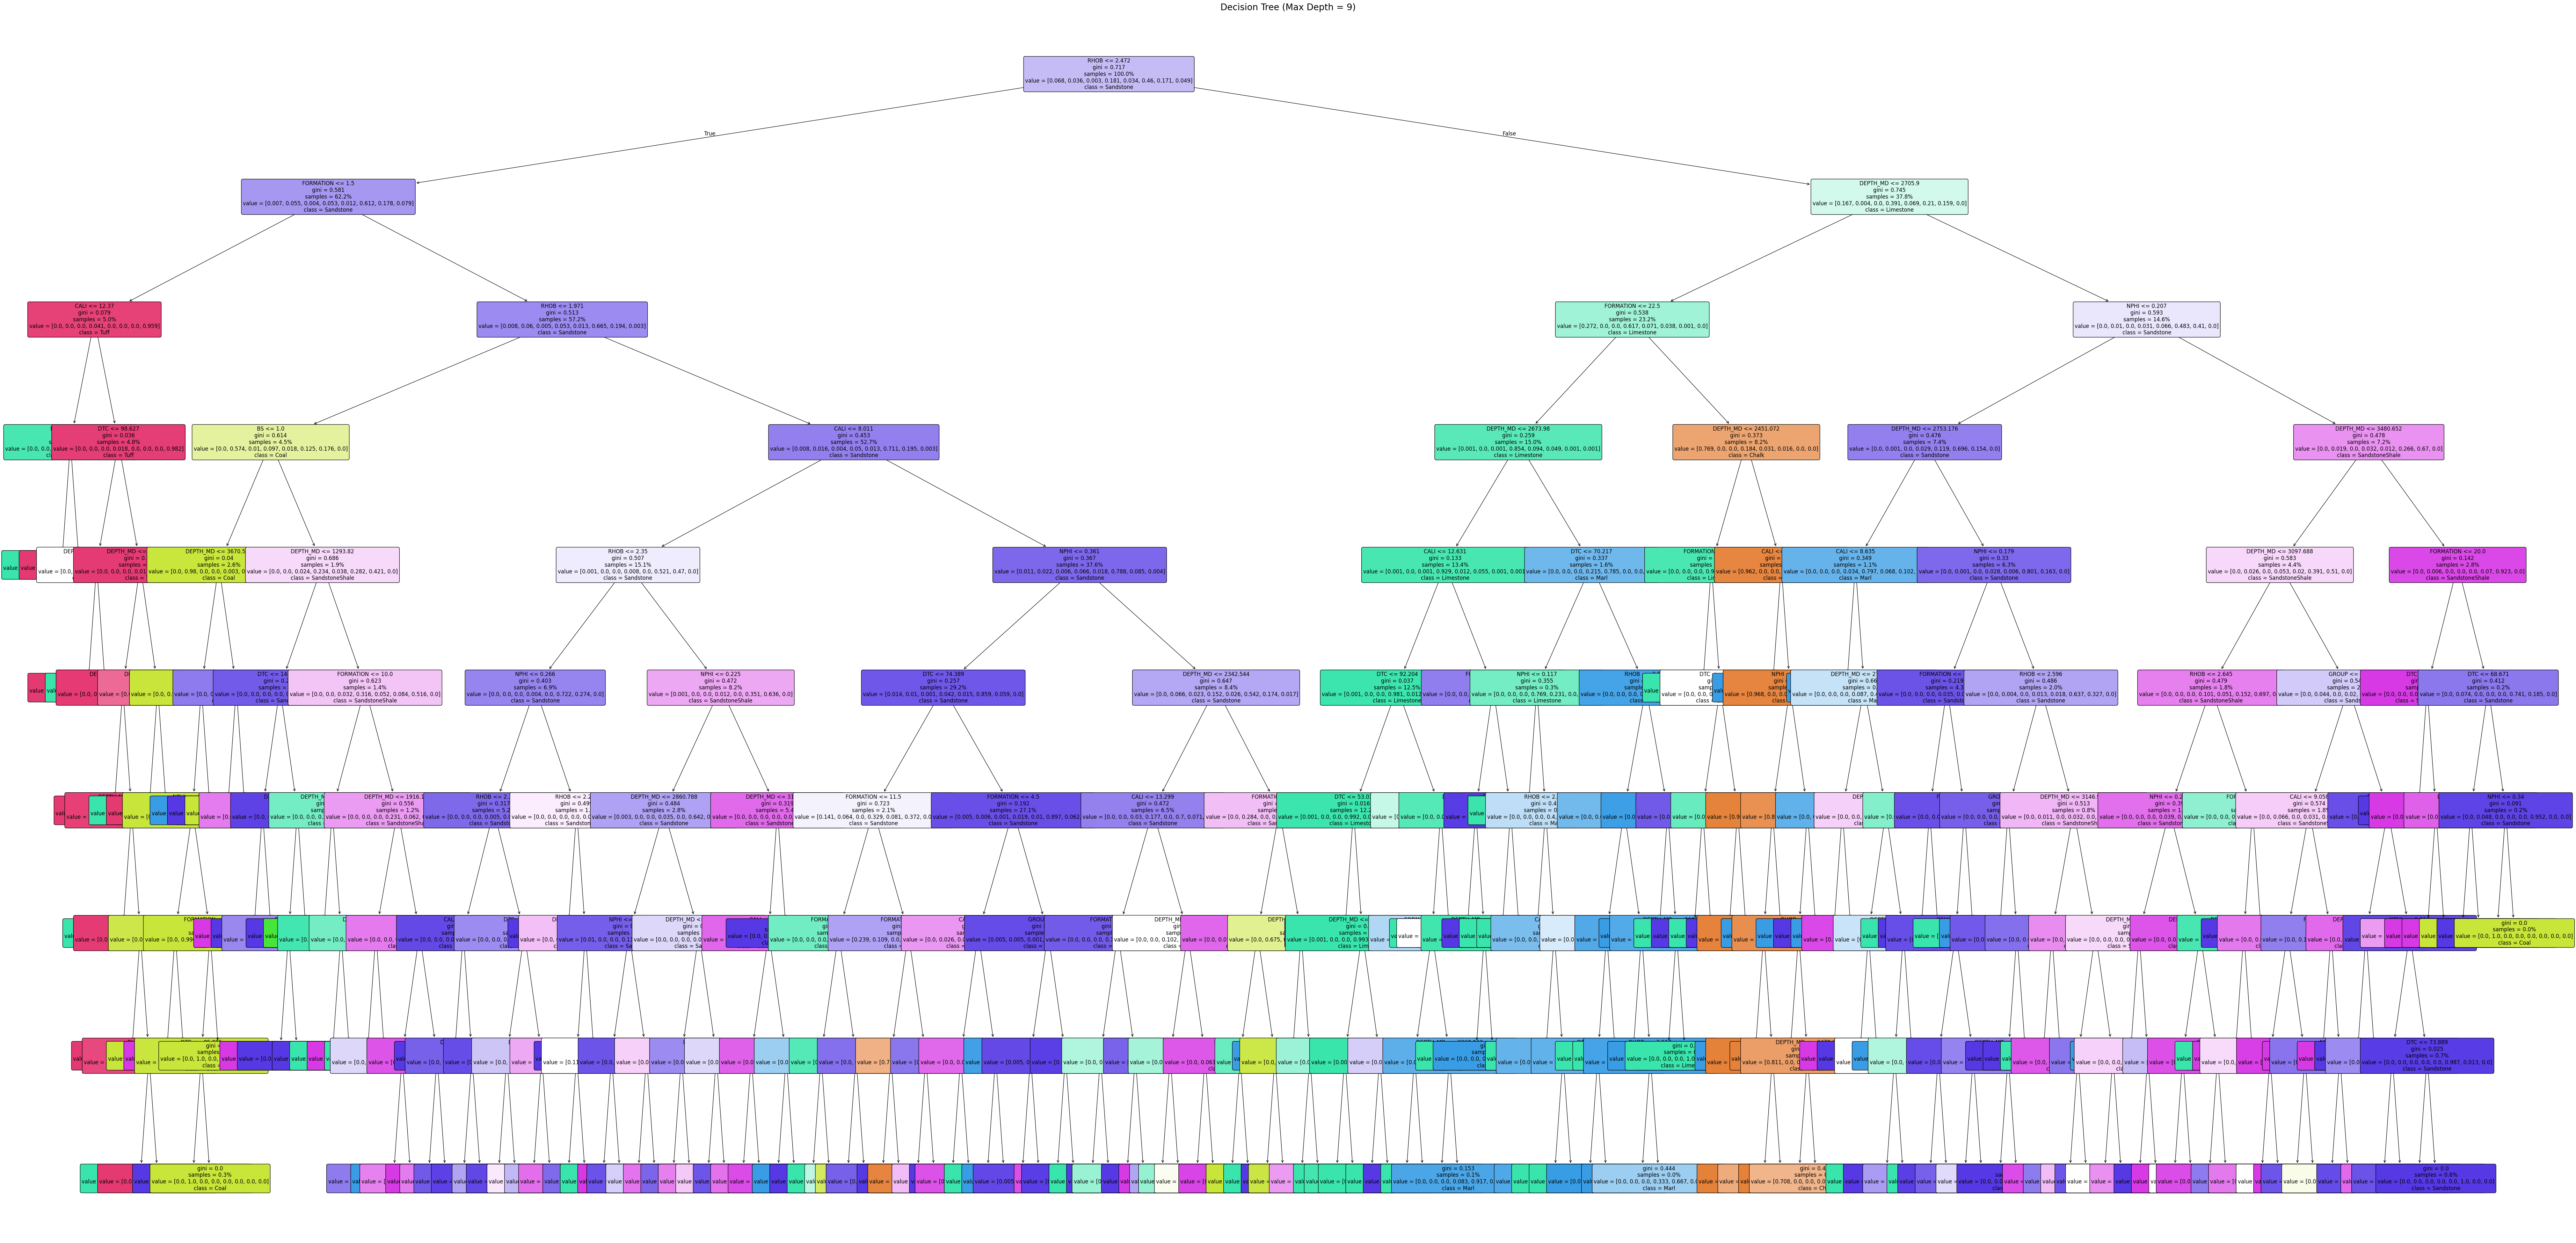

In [168]:
DT4 = DecisionTreeClassifier(max_depth=9, min_samples_split=4, random_state=42)
# Fit model
DTModel4 = DT4.fit(X_train, y_train)
# Predictions for evaluation
y_pred2 = DTModel4.predict(X_test)
# Accuracy calculation
acc2 = accuracy_score(y_test, y_pred2)
# Print accuracy
print(f"Accuracy of Decision Tree 3: {acc2:.4f}")
# Confusion matrix for each model
cm2 = confusion_matrix(y_test, y_pred2)
# Plot confusion matrices
plot_confusion_matrix(cm2, 9)
# Plot decision tree
plt.figure(figsize=(100, 50)) 
plot_tree(DTModel4, feature_names=feature_names, class_names=class_names, filled=True, rounded=True, fontsize=12, impurity=True, proportion=True)
plt.title("Decision Tree (Max Depth = 9)", fontsize=20)
plt.show()

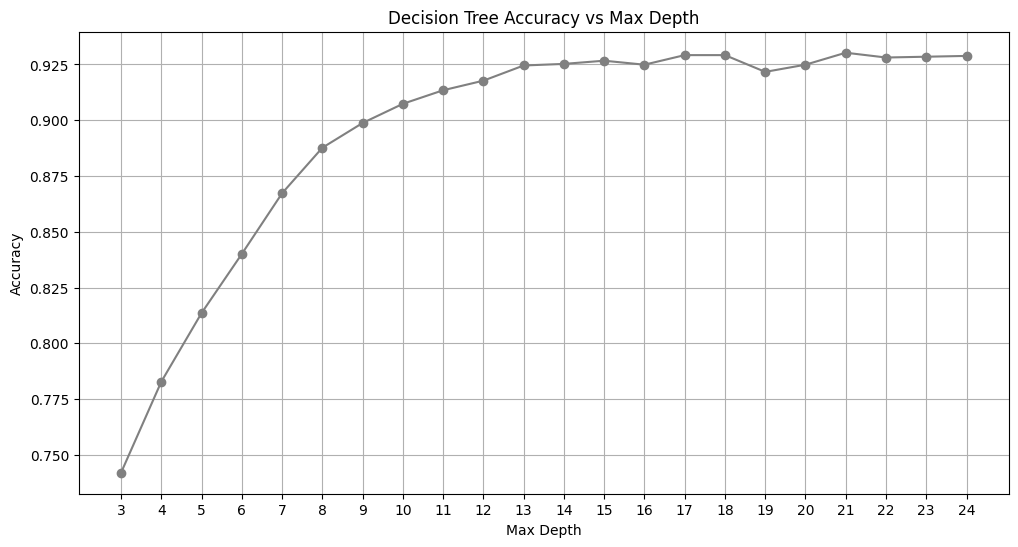

In [166]:
test_accuracies = []
max_depths = range(3, 25)

# Loop through different max depths, train model, and calculate accuracy
for depth in max_depths:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    test_accuracies.append(accuracy)

# Plot the accuracies
plt.figure(figsize=(12, 6))
plt.plot(max_depths, test_accuracies, marker='o', color='grey')
plt.title('Decision Tree Accuracy vs Max Depth')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.xticks(max_depths)
plt.grid()
plt.show()
